In [1]:
import pandas as pd, numpy as np, lightgbm as lgb
from sklearn.model_selection import train_test_split
from pathlib import Path

PARQUET = Path("../data/features/features_202507.parquet")
df = pd.read_parquet(PARQUET).dropna(subset=["label"])

# === MISMAS COLUMNAS QUE EN ml.train =========================
OBJ_COLS = df.select_dtypes(include="object").columns
X_cols = [c for c in df.columns if c not in
          ("label", "pnl", "timestamp", "ts", "pnl_pct") and
          c not in OBJ_COLS]

# split temporal: 80 % train, 20 % valid
df = df.sort_values("timestamp")
split_idx = int(len(df) * 0.8)
train_df, valid_df = df.iloc[:split_idx], df.iloc[split_idx:]

print(train_df.shape, valid_df.shape)


(257075, 22) (64269, 22)


In [2]:
ratio = 0.25                # 0 = tomar todo; 0.25 ≈ reduce clase 0 al 25 %
train_under = (train_df
               .groupby("label", group_keys=False)
               .apply(lambda x: x.sample(frac=ratio if x.name == 0 else 1,
                                         random_state=42)))
print(train_under["label"].value_counts())


label
0    57429
1    27360
Name: count, dtype: int64


C:\Users\monmo10\AppData\Local\Temp\ipykernel_27624\2150453090.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=ratio if x.name == 0 else 1,


In [3]:
from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

pos, neg = np.bincount(train_under["label"].astype(int))
scale_pos_weight = neg / pos

lgb_est = lgb.LGBMClassifier(
    objective="binary",
    metric="auc",
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    n_estimators=500,                    # suficiente, hay early stopping
    n_jobs=-1
)

param_dist = {
    "num_leaves":      randint(31, 128),
    "min_data_in_leaf":randint(40, 120),
    "max_depth":       randint(4, 8),
    "feature_fraction":uniform(0.7, 0.3),   # 0.7-1.0
    "bagging_fraction":uniform(0.7, 0.3),
    "bagging_freq":    randint(1, 3),
}

rs = RandomizedSearchCV(
    lgb_est,
    param_distributions=param_dist,
    n_iter=25,
    scoring=make_scorer(roc_auc_score, needs_proba=True),
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

rs.fit(train_under[X_cols], train_under["label"],
       eval_set=[(valid_df[X_cols], valid_df["label"])],
       callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])

print("Mejor AUC CV:", rs.best_score_)
best_model = rs.best_estimator_


Fitting 3 folds for each of 25 candidates, totalling 75 fits


d:\Dev\Python\memebot3\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan]
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] feature_fraction is set=0.7550304369598491, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7550304369598491
[LightGBM] [Warning] bagging_fraction is set=0.8123620356542087, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8123620356542087
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] feature_fraction is set=0.7550304369598491, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7550304369598491
[LightGBM] [Warning] bagging_fraction is set=0.8123620356542087, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8123620356542087
[LightGBM] [Warning] bagging_freq is set=1

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] feature_fraction is set=0.7550304369598491, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7550304369598491
[LightGBM] [Warning] bagging_fraction is set=0.8123620356542087, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8123620356542087
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1


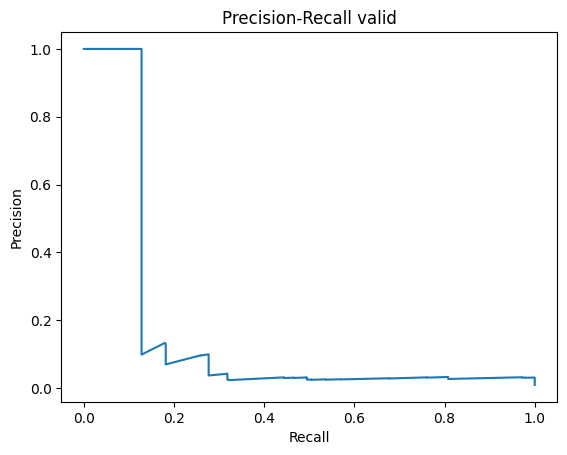

Threshold @80 % precisión ≈ 0.79


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

y_scores = best_model.predict_proba(valid_df[X_cols])[:, 1]
prec, rec, thr = precision_recall_curve(valid_df["label"], y_scores)

plt.plot(rec, prec); plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall valid"); plt.show()

# Ejemplo: umbral con precisión ≥ 80 %
target_prec = 0.80
thr_opt = thr[np.argmax(prec[:-1] >= target_prec)]
print(f"Threshold @80 % precisión ≈ {thr_opt:.2f}")


In [5]:
import joblib, pathlib, json, time

MODEL_PATH = pathlib.Path("../ml/model.pkl")
META_PATH  = MODEL_PATH.with_suffix(".meta.json")

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model.booster_, MODEL_PATH)

# meta (opcional)
auc_valid = roc_auc_score(valid_df["label"], y_scores)
META_PATH.write_text(json.dumps({
    "auc":       auc_valid,
    "trained":   time.strftime("%Y-%m-%d %H:%M:%S"),
    "features":  X_cols,
    "params":    best_model.get_params(),
}, indent=2))

print("✅  Modelo LightGBM guardado en", MODEL_PATH)


✅  Modelo LightGBM guardado en ..\ml\model.pkl
